In [2]:
#写一个大循环，循环不同的分辨率
# 匹配数目与平均降水
from scipy import stats
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeat
import matplotlib.pyplot as plt
from cartopy.io.shapereader import Reader
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.feature import ShapelyFeature
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import BoundaryNorm
a=0.2
p = int(7 / a)
q = int(11 / a)

c:\ProgramData\miniconda3\envs\pystudy\Lib\site-packages\pyproj\__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [40]:
gauge_pre_grided=np.load('gauge_pre_grided.npy')
sate_pre=np.load("precip_all_hour_satellite.npy")
# sate_pre=satellite_pre.transpose(0, 2, 1)
#两个数据同时小于0.1时表示没有误差
sate_pre[(sate_pre<0.1) & (gauge_pre_grided<0.1)]=0
gauge_pre_grided[(sate_pre<0.1) & (gauge_pre_grided<0.1)]=0
pre_minus = sate_pre - gauge_pre_grided

In [41]:
#添加误差
def func(x, a, b):
    return a * np.exp(-b * x)

def get_ab_values(rain):
    if  0.1< rain < 2:
        return 0.45131016517318423, 0.16169399717438698
    elif 2 <= rain < 4:
        return  1.6794847980908945, 0.16198899816352366
    elif 4 <= rain < 8:
        return 3.437138732494024, 0.16260406256981108
    elif rain >= 8:
        return 7.550905959233764, 0.16581205841013613
    else:
        return -9999,-9999


In [4]:
get_ab_values(np.nan)[0]>-999

False

In [39]:
gauge_pre_num=np.load("gauge_pre_num.npy")

In [6]:
gauge_pre_num.shape

(43848, 35, 55)

In [47]:
np.nansum(quyupre[3])/5

np.float64(693.8866666666668)

In [ ]:
np.nansum(quyupre[1])

In [18]:
np.nansum(quyupre[0])/5

np.float64(1195.5386611566908)

In [8]:
print(num[1],num[0],num[2],num[3])

[3. 3. 3. ... 3. 3. 3.] [18. 18. 18. ... 20. 20. 20.] [14. 14. 14. ... 13. 13. 13.] [3. 3. 3. ... 3. 3. 3.]


In [42]:
quyupre={}
quyupre[1]=gauge_pre_grided[:,12,28]
quyupre[0]=gauge_pre_grided[:,10,38]
quyupre[2]=gauge_pre_grided[:,2,34]
quyupre[3]=gauge_pre_grided[:,29,41]

satepre={}
satepre[1]=sate_pre[:,12,28]
satepre[0]=sate_pre[:,10,38]
satepre[2]=sate_pre[:,2,34]
satepre[3]=sate_pre[:,29,41]

num={}
num[1]=gauge_pre_num[:,12,28]
num[0]=gauge_pre_num[:,10,38]
num[2]=gauge_pre_num[:,2,34]
num[3]=gauge_pre_num[:,29,41]

error1={}#卫星-地基
error1[1]=pre_minus[:,12,28]
error1[0]=pre_minus[:,10,38]
error1[2]=pre_minus[:,2,34]
error1[3]=pre_minus[:,29,41]

error2={}#地基站本身误差
for i in range(4):
    error2[i]=np.full((43848),np.nan)
for j in range(43848):
    bb=gauge_pre_grided[:,12,28][j]
    aa=gauge_pre_grided[:,10,38][j]
    cc=gauge_pre_grided[:,2,34] [j] 
    dd=gauge_pre_grided[:,29,41] [j]
    if get_ab_values(aa)[0]>-999:
        error2[0][j]=func(num[0][j],get_ab_values(aa)[0],get_ab_values(aa)[1])
    if get_ab_values(bb)[0]>-999: 
        error2[1][j]=func(num[1][j],get_ab_values(bb)[0],get_ab_values(bb)[1])
    if get_ab_values(cc)[0]>-999:
        error2[2][j]=func(num[2][j],get_ab_values(cc)[0],get_ab_values(cc)[1])
    if get_ab_values(dd)[0]>-999:
        error2[3][j]=func(num[3][j],get_ab_values(dd)[0],get_ab_values(dd)[1])

In [6]:
pd.date_range('2020-1','2024-12',freq='4ME')

DatetimeIndex(['2020-01-31', '2020-05-31', '2020-09-30', '2021-01-31',
               '2021-05-31', '2021-09-30', '2022-01-31', '2022-05-31',
               '2022-09-30', '2023-01-31', '2023-05-31', '2023-09-30',
               '2024-01-31', '2024-05-31', '2024-09-30'],
              dtype='datetime64[ns]', freq='4ME')

In [7]:
plt.rcParams["font.sans-serif"] = ["Arial"]  # 用于显示中文
plt.rcParams["axes.unicode_minus"] = False

In [8]:

data={}
for i in range(4):
    data[i]=[]
    for j in range(len(error1[0])):
        data[i].append(np.max([0,np.abs(error1[i][j])-error2[i][j]]))

In [9]:
date_range=pd.date_range(start="2020-1-1 00:00:00", end="2024-12-31 23:00", freq="h")
monthly_pre={}
error_sate={}
error_gauge={}
monthly_sate={}
for i in range(4):
    df = pd.DataFrame({'precipitation': quyupre[i],
                       'satepre':satepre[i],
                       'error1':error1[i],
                       'error2':error2[i],}, index=date_range)
    monthly_pre[i] = df['precipitation'].resample('ME').mean()
    monthly_sate[i]= df['satepre']      .resample('ME').mean()
    error_sate[i]= df['error1']         .resample('ME').mean()
    error_gauge[i]= df['error2']        .resample('ME').mean()


In [41]:
np.abs(error_sate[1]).mean()

np.float64(1.221391521427327)

In [10]:
error_sate[3][monthly_pre[3]<0.1]=np.nan
error_sate[2][monthly_pre[2]<0.1]=np.nan
error_sate[0][monthly_pre[0]<0.1]=np.nan
error_sate[1][monthly_pre[1]<0.1]=np.nan
print(error_sate[2].mean(),error_sate[3].mean())

0.08121933478493844 0.09984544778858499


Text(0.03, 0.5, 'precipitation (mm h$^{-1}$)')

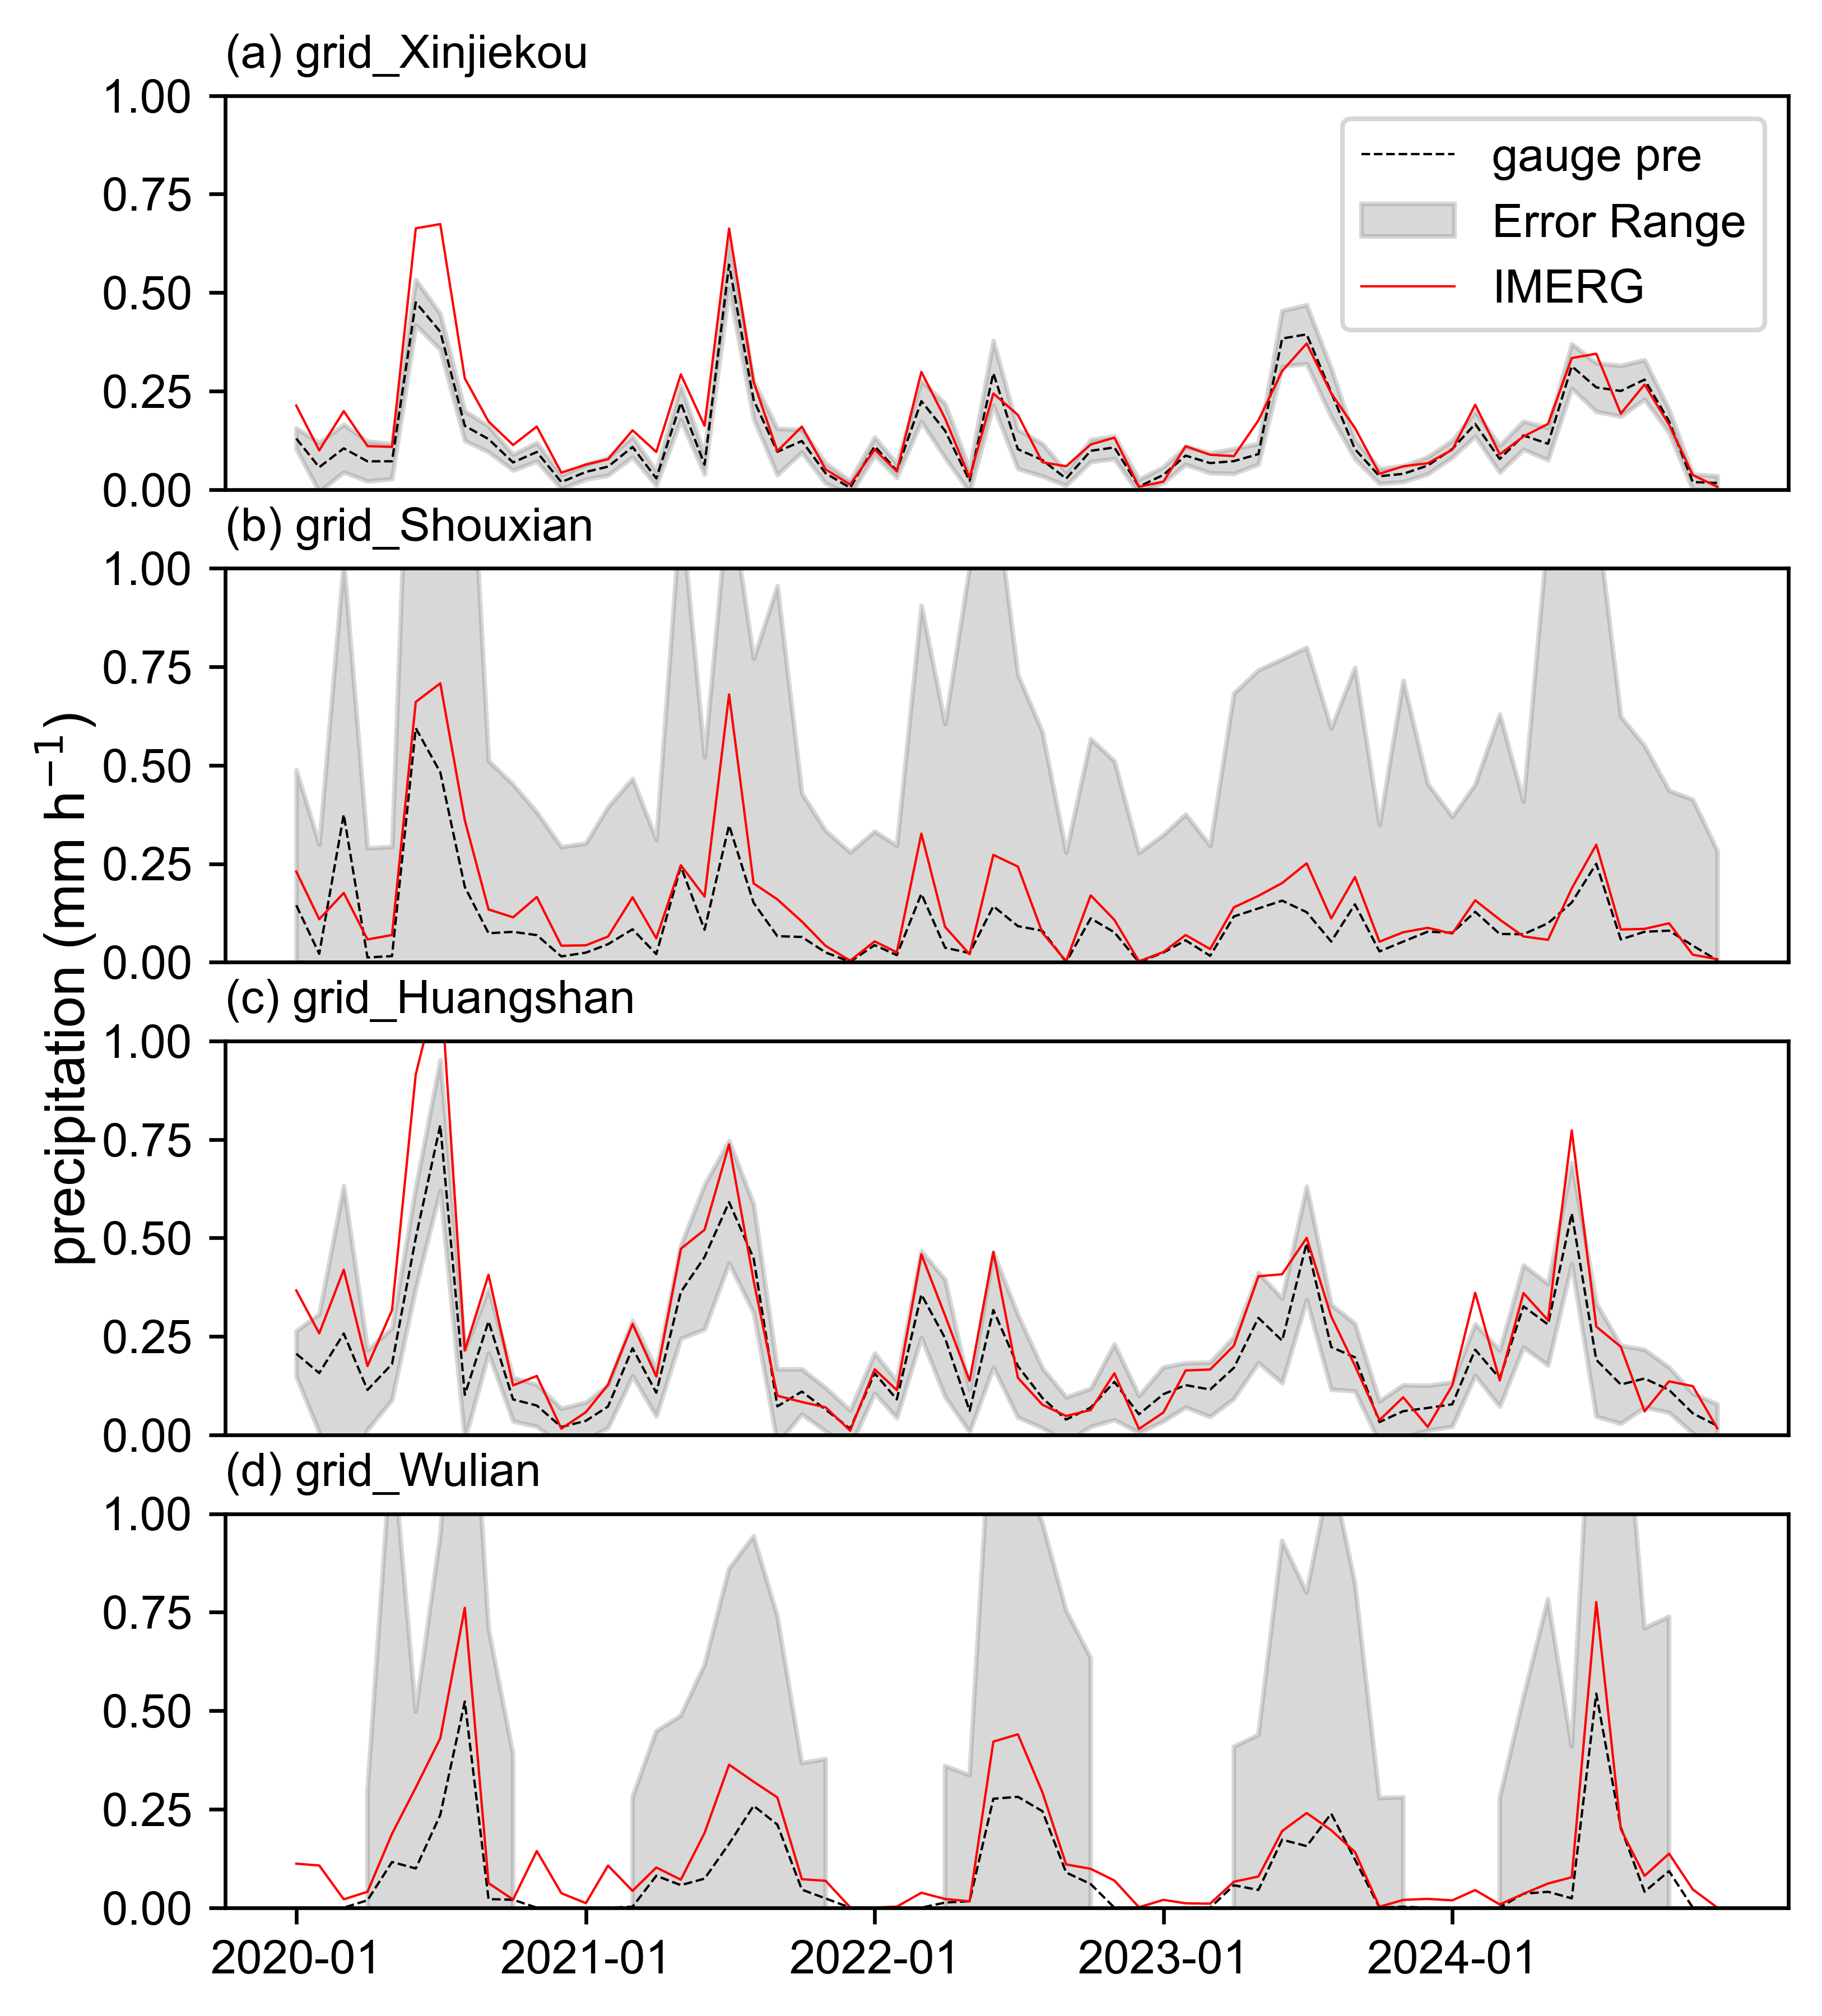

In [13]:
years = pd.date_range(start="2020-1-1", end="2024-12-31 23:00", freq="ME")

fig, axs = plt.subplots(4, 1, figsize=(6,7 ), dpi=600,)
for i,ax in enumerate(axs):
    ax.plot(years, monthly_pre[i], 'k--',linewidth=0.5, label='gauge pre')  # 黑色实线
    # 填充误差区域
    ax.fill_between(
        years,                   # x 坐标
        monthly_pre[i] - error_gauge[i],  # 下限
        monthly_pre[i] + error_gauge[i],  # 上限
        color='gray',            # 填充颜色
        alpha=0.3,               # 透明度 (0=完全透明, 1=完全不透明)
        label='Error Range'      # 图例标签
    )
    # # 填充误差区域
    # ax.fill_between(
    #     years,                   # x 坐标
    #     monthly_pre[i] - error_sate[i],  # 下限
    #     monthly_pre[i] + error_sate[i],  # 上限
    #     color='r',            # 填充颜色
    #     alpha=0.3,               # 透明度 (0=完全透明, 1=完全不透明)
    #     label='Error Range'      # 图例标签
    # )
    ax.plot(years, monthly_sate[i], 'r-',linewidth=0.5, label='IMERG')  # 黑色实线
    # ax.errorbar(
    #     years,                   # x轴数据
    #     monthly_sate[i],         # y轴数据（平均值）
    #     yerr=np.abs(error_sate[i]),      # 误差范围
    #     fmt='-',                # 标记和线条样式
    #     color='r',         # 使用颜色循环
    #     linewidth=0.3,           # 线宽
    #     markersize=1,            # 标记大小
    #     capsize=1,               # 误差线帽的大小
    #     label='satellite pre'         # 图例标签
    # )

    # ax.set_ylabel('rain rate(mm/h)')
    ax.set_xticks([])
    ax.set_ylim(0,1.)
    if i==0:
        ax.legend()
    # ax_right.tick_params(axis='y', labelcolor='red')
axs[3].set_xticks(pd.date_range('2020-1','2024-12',freq='12ME'))
import matplotlib.dates as mdates
date_format = mdates.DateFormatter('%Y-%m')  # %Y 表示年，%m 表示月
axs[3].xaxis.set_major_formatter(date_format)
axs[0].set_title('(a) grid_Xinjiekou',fontsize=10,loc='left')
axs[1].set_title('(b) grid_Shouxian',fontsize=10,loc='left')
axs[2].set_title('(c) grid_Huangshan',fontsize=10,loc='left')
axs[3].set_title('(d) grid_Wulian',fontsize=10,loc='left')
fig.text(0.03, 0.5, 'precipitation (mm h$^{-1}$)', va='center', rotation='vertical',fontsize=12)

# fig.text(0.95, 0.5, 'error range (mm/h)', va='center', rotation='vertical',fontsize=12,c='r')